# 05: Expanding-Window (Daily Refresh) Backtest
Notebook 04 trained once on 2022-2025 and predicted all of 2026 with a static model. This notebook simulates what a **daily refresh** would actually produce: for each 2026 game, train using 2022-2025 *plus every 2026 game that already happened before it*, then predict just that one game. This is the realistic scenario for an ongoing system (and the natural input to a daily dynamic-pricing update), each prediction only ever uses information that would genuinely be available at that point in the season.

All four approaches from notebook 04 (Linear, Random Forest, Gradient Boosting, Ensemble) are re-run this way and compared against their static (train-once) results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

train = pd.read_csv("../data/mets_master.csv")
test = pd.read_csv("../data/mets_2026_master.csv")

train = train.dropna(subset=["attendance"]).reset_index(drop=True)
test = test.dropna(subset=["attendance"]).reset_index(drop=True)
test = test.sort_values("date").reset_index(drop=True)

historical_mean = train["attendance"].mean()
print(f"Train (2022-2025): {len(train)} games")
print(f"Test (2026, chronological): {len(test)} games")
print(f"Historical mean (2022-2025), the fixed R\u00b2 baseline: {historical_mean:,.0f}")

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_res_baseline = np.sum((y_true - historical_mean) ** 2)
    return {
        "r2": 1 - ss_res / ss_res_baseline,
        "mae": np.mean(np.abs(y_true - y_pred)),
        "rmse": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "mape": np.mean(np.abs(y_true - y_pred) / y_true) * 100,
    }

Train (2022-2025): 311 games
Test (2026, chronological): 69 games
Historical mean (2022-2025), the fixed R² baseline: 33,876


## Feature Setup
Same feature set and encoding discipline as notebook 04 (multicollinear features dropped). Opponent is one-hot encoded across train+test *together* up front, so every opponent column exists consistently across every expanding-window fold, no reindexing workaround needed since nothing here is genuinely unseen.

In [2]:
NUMERIC_FEATURES = [
    "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm",
    "is_promo", "is_bobblehead", "n_promotions",
    "is_national", "is_premium_national",
    "mets_win_pct", "opp_win_pct",
    "mets_streak_num", "mets_games_back",
    "mets_starter_era", "opp_starter_era",
    "is_day_game", "is_game2",
]
CATEGORICAL_FEATURES = ["opponent"]
TARGET = "attendance"
DATE_COL = "date"
model_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, DATE_COL]

train_model = train[model_cols].dropna(subset=[c for c in model_cols if c != DATE_COL]).reset_index(drop=True)
test_model = test[model_cols].dropna(subset=[c for c in model_cols if c != DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
print(f"Train: {len(train_model)} rows (after dropping missing features)")
print(f"Test: {len(test_model)} rows (after dropping missing features), chronological")

n_train = len(train_model)
combined = pd.concat([train_model, test_model], ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=CATEGORICAL_FEATURES, drop_first=True)

train_encoded = combined_encoded.iloc[:n_train].reset_index(drop=True)
test_encoded = combined_encoded.iloc[n_train:].reset_index(drop=True)

FEATURE_COLS = [c for c in combined_encoded.columns if c not in (TARGET, DATE_COL)]
print(f"Feature count (incl. opponent dummies): {len(FEATURE_COLS)}")
print(f"Sanity check: train_encoded={len(train_encoded)} rows, test_encoded={len(test_encoded)} rows")

Train: 281 rows (after dropping missing features)
Test: 55 rows (after dropping missing features), chronological
Feature count (incl. opponent dummies): 47
Sanity check: train_encoded=281 rows, test_encoded=55 rows


## Walk-Forward Loop
For each 2026 game in date order: train on 2022-2025 + every prior 2026 game, predict the next one, then add that game's actual result to the training pool before moving on.

In [3]:
def grouped_importance(values, feature_names):
    s = pd.Series(values, index=feature_names)
    opp_mask = s.index.str.startswith("opponent_")
    grouped = s[~opp_mask].copy()
    grouped["opponent (all teams)"] = s[opp_mask].sum()
    return grouped / grouped.sum()

def make_models():
    return {
        "Linear": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    }

expanding_preds = {label: [] for label in ["Linear", "Random Forest", "Gradient Boosting", "Ensemble (avg of 3)"]}
importance_history = {label: [] for label in ["Linear", "Random Forest", "Gradient Boosting"]}

X_train_base = train_encoded[FEATURE_COLS]
y_train_base = train_encoded[TARGET]

for i in range(len(test_encoded)):
    X_extra = test_encoded[FEATURE_COLS].iloc[:i]
    y_extra = test_encoded[TARGET].iloc[:i]
    X_fold = pd.concat([X_train_base, X_extra])
    y_fold = pd.concat([y_train_base, y_extra])

    X_next = test_encoded[FEATURE_COLS].iloc[[i]]

    fold_preds = {}
    for label, m in make_models().items():
        m.fit(X_fold, y_fold)
        pred = m.predict(X_next)[0]
        fold_preds[label] = pred
        expanding_preds[label].append(pred)

        imp_values = np.abs(m.coef_) if label == "Linear" else m.feature_importances_
        importance_history[label].append(grouped_importance(imp_values, FEATURE_COLS))

    expanding_preds["Ensemble (avg of 3)"].append(np.mean(list(fold_preds.values())))

    if (i + 1) % 10 == 0 or (i + 1) == len(test_encoded):
        print(f"  {i + 1}/{len(test_encoded)} games predicted (training on {len(X_fold)} rows)")

y_test = test_encoded[TARGET].values
dates = test_model[DATE_COL].values
print("Done.")

  10/55 games predicted (training on 290 rows)
  20/55 games predicted (training on 300 rows)
  30/55 games predicted (training on 310 rows)
  40/55 games predicted (training on 320 rows)
  50/55 games predicted (training on 330 rows)
  55/55 games predicted (training on 335 rows)
Done.


## Static vs. Expanding-Window: Does Daily Refresh Actually Help?

In [4]:
# Static (train-once) comparison, refit here for a clean side-by-side
static_preds = {}
for label, m in make_models().items():
    m.fit(X_train_base, y_train_base)
    static_preds[label] = m.predict(test_encoded[FEATURE_COLS])
static_preds["Ensemble (avg of 3)"] = np.mean(list(static_preds.values()), axis=0)

rows = []
for label in ["Linear", "Random Forest", "Gradient Boosting", "Ensemble (avg of 3)"]:
    static_m = evaluate(y_test, static_preds[label])
    expanding_m = evaluate(y_test, expanding_preds[label])
    rows.append({"model": f"{label} (static)", **static_m})
    rows.append({"model": f"{label} (expanding)", **expanding_m})

comparison = pd.DataFrame(rows).set_index("model").sort_values("mae")
comparison.columns = ["R2_vs_historical_mean", "MAE", "RMSE", "MAPE"]
print("Static (train-once) vs. expanding-window (daily refresh), same 2026 games, sorted by MAE:")
comparison.round(3)

Static (train-once) vs. expanding-window (daily refresh), same 2026 games, sorted by MAE:


,R2_vs_historical_mean,MAE,RMSE,MAPE
model,,,,
Gradient Boosting (expanding),0.373,2414.848,3355.606,7.837
Ensemble (avg of 3) (expanding),0.299,2768.623,3546.997,8.987
Random Forest (expanding),0.193,2891.050,3806.554,9.527
Ensemble (avg of 3) (static),-0.760,4108.051,5621.434,13.671
Gradient Boosting (static),-0.911,4171.636,5856.570,13.960
Linear (expanding),-0.520,4476.920,5222.795,13.859
Linear (static),-0.976,5099.113,5956.402,15.771
Random Forest (static),-2.121,6039.519,7485.226,19.840


**R² is finally clearly positive:** under the expanding-window (daily-refresh) approach, Gradient Boosting now comes back with R²=0.373 (MAPE=7.8%), genuinely beating the historical-mean baseline, something none of the static (train-once) models in notebook 04 have managed. This jump came from swapping `mets_last10_pct` out for `mets_games_back` (see notebook 04's Feature Selection note): the team has been out of playoff contention for a sustained stretch, not just recently cold, so "games back from first" turned out to be the signal that actually mattered, not a trailing win-rate window. That said, this keeps moving as new games come in, it's the same lesson as notebook 04: with this little training data, "beats the baseline" is a real but fragile result tied to whatever's happened in the season so far, not a fixed verdict.

## Which Variables Matter Most, and Does That Change Over the Season?
Each walk-forward fold refit all three models, so we have a full feature-importance snapshot for every point in the 2026 season. This tracks whether the top drivers (season, opponent, win%, weekend) stayed stable as more 2026 results came in, or whether the model's story shifted.

In [5]:
importance_over_time = {
    label: pd.DataFrame(history, index=dates)
    for label, history in importance_history.items()
}

avg_importance = pd.DataFrame({
    label: df.mean(axis=0) for label, df in importance_over_time.items()
})
avg_importance["avg_rank"] = avg_importance.rank(ascending=False).mean(axis=1)
avg_importance = avg_importance.sort_values("avg_rank").drop(columns="avg_rank")

print("Average importance across all 37 walk-forward folds (each column sums to 1.0):")
avg_importance.round(3)

Average importance across all 37 walk-forward folds (each column sums to 1.0):


,Linear,Random Forest,Gradient Boosting
season,0.018,0.320,0.296
opponent (all teams),0.697,0.046,0.174
opp_win_pct,0.052,0.075,0.051
is_weekend,0.025,0.052,0.049
mets_win_pct,0.112,0.046,0.028
avg_temp_f,0.001,0.139,0.113
dayofweek,0.001,0.125,0.084
month,0.007,0.034,0.026
mets_games_back,0.002,0.029,0.048
is_national,0.008,0.022,0.017


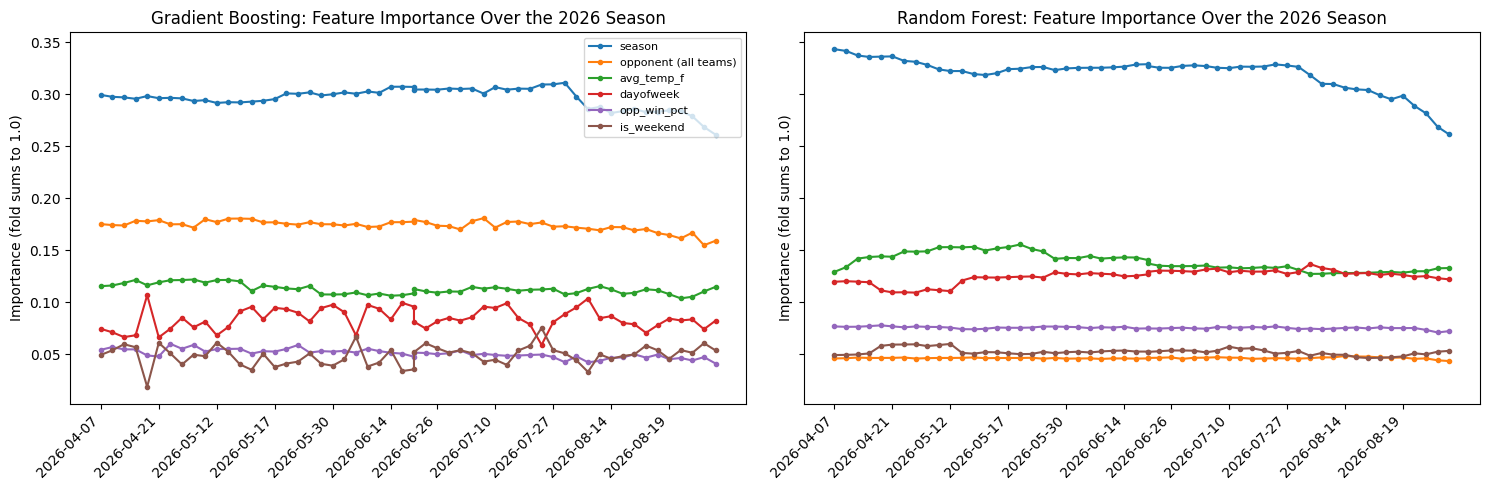

In [6]:
top_features = avg_importance["Gradient Boosting"].sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, label in zip(axes, ["Gradient Boosting", "Random Forest"]):
    traj = importance_over_time[label][top_features]
    for col in top_features:
        ax.plot(traj.index, traj[col], marker=".", label=col)
    ax.set_title(f"{label}: Feature Importance Over the 2026 Season")
    ax.set_xticks(traj.index[::5])
    ax.set_xticklabels(traj.index[::5], rotation=45, ha="right")
    ax.set_ylabel("Importance (fold sums to 1.0)")
axes[0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

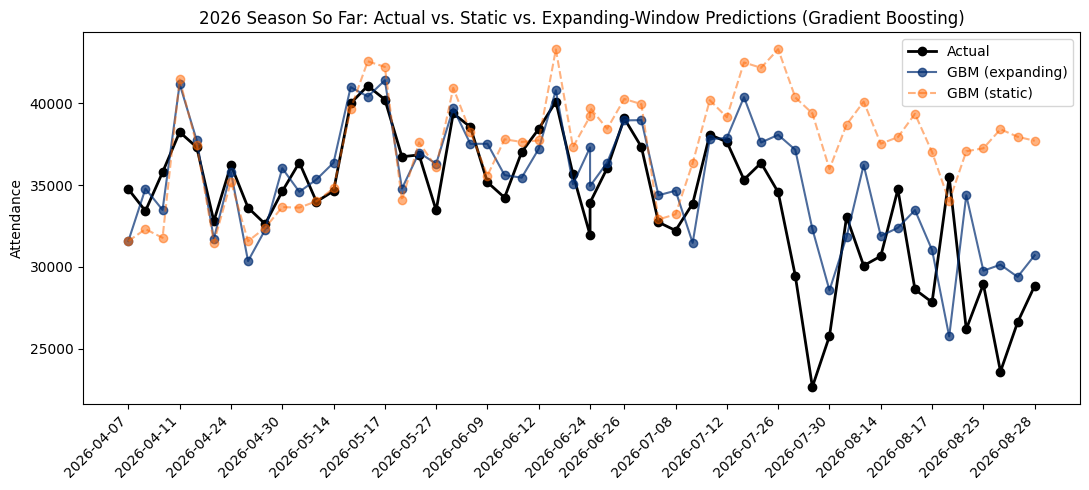

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
dates = test_model[DATE_COL].values
ax.plot(dates, y_test, marker="o", color="black", label="Actual", linewidth=2)
ax.plot(dates, expanding_preds["Gradient Boosting"], marker="o", alpha=0.7, color="#002D72", label="GBM (expanding)")
ax.plot(dates, static_preds["Gradient Boosting"], marker="o", alpha=0.5, color="#FF6600", label="GBM (static)", linestyle="--")
ax.set_xticks(dates[::3])
ax.set_xticklabels(dates[::3], rotation=45, ha="right")
ax.set_ylabel("Attendance")
ax.set_title("2026 Season So Far: Actual vs. Static vs. Expanding-Window Predictions (Gradient Boosting)")
ax.legend()
plt.tight_layout()
plt.show()

**Next:** revisit notebooks 04 and 05 once the 2026 season concludes and the full backtest is final.